In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print (pd.__version__)
print (np.__version__)

2.3.3
2.3.5


In [2]:
cft_pdt_data = pd.read_csv("counterfeit_products_preprocessed_v2.csv")
cft_pdt_data.shape

(5000, 28)

In [3]:
cft_pdt_data.head()

,price,seller_rating,seller_reviews,product_images,description_length,shipping_time_days,spelling_errors,domain_age_days,contact_info_complete,return_policy_clear,...,ip_location_mismatch,is_counterfeit,seller_country,shipping_origin,brand_suspicious,category_Cosmetics,category_Electronics,category_Fashion,category_Luxury Goods,category_Pharmaceuticals
0,277.20,3.500000,890,4,128.0,21.0,0,1440,0,1,...,0,0,1,6,0,0,0,1,0,0
1,89.18,3.978268,1859,3,224.0,31.0,4,206,0,0,...,1,1,5,5,0,0,1,0,0,0
2,168.40,2.700000,1096,2,98.0,10.0,0,1069,1,1,...,0,1,7,1,1,0,0,1,0,0
3,130.98,3.100000,1296,3,255.0,22.0,0,514,1,1,...,0,0,7,6,0,0,0,0,0,0
4,5.00,2.600000,0,2,20.0,32.0,5,5,0,0,...,0,1,8,9,0,0,0,0,0,1


In [4]:
cft_pdt_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   price                     5000 non-null   float64
 1   seller_rating             5000 non-null   float64
 2   seller_reviews            5000 non-null   int64  
 3   product_images            5000 non-null   int64  
 4   description_length        5000 non-null   float64
 5   shipping_time_days        5000 non-null   float64
 6   spelling_errors           5000 non-null   int64  
 7   domain_age_days           5000 non-null   int64  
 8   contact_info_complete     5000 non-null   int64  
 9   return_policy_clear       5000 non-null   int64  
 10  payment_methods_count     5000 non-null   int64  
 11  views                     5000 non-null   int64  
 12  purchases                 5000 non-null   int64  
 13  wishlist_adds             5000 non-null   int64  
 14  certific

In [5]:
cft_pdt_data.isnull().sum()

price                       0
seller_rating               0
seller_reviews              0
product_images              0
description_length          0
shipping_time_days          0
spelling_errors             0
domain_age_days             0
contact_info_complete       0
return_policy_clear         0
payment_methods_count       0
views                       0
purchases                   0
wishlist_adds               0
certification_badges        0
warranty_months             0
bulk_orders                 0
unusual_payment_patterns    0
ip_location_mismatch        0
is_counterfeit              0
seller_country              0
shipping_origin             0
brand_suspicious            0
category_Cosmetics          0
category_Electronics        0
category_Fashion            0
category_Luxury Goods       0
category_Pharmaceuticals    0
dtype: int64

In [6]:
quan=[]
qual=[]
for columnName in cft_pdt_data.columns:
    #print(columnName)
    if(cft_pdt_data[columnName].dtype=='O'):
        #print("qual")
        qual.append(columnName)
    else:
        #print("quan")
        quan.append(columnName)

In [7]:
quan

['price',
 'seller_rating',
 'seller_reviews',
 'product_images',
 'description_length',
 'shipping_time_days',
 'spelling_errors',
 'domain_age_days',
 'contact_info_complete',
 'return_policy_clear',
 'payment_methods_count',
 'views',
 'purchases',
 'wishlist_adds',
 'certification_badges',
 'warranty_months',
 'bulk_orders',
 'unusual_payment_patterns',
 'ip_location_mismatch',
 'is_counterfeit',
 'seller_country',
 'shipping_origin',
 'brand_suspicious',
 'category_Cosmetics',
 'category_Electronics',
 'category_Fashion',
 'category_Luxury Goods',
 'category_Pharmaceuticals']

In [8]:
qual

[]

In [9]:
quan = ['price', 'seller_rating', 'seller_reviews', 'product_images',
        'description_length', 'shipping_time_days', 'spelling_errors',
        'domain_age_days', 'payment_methods_count', 'views', 'purchases',
        'wishlist_adds', 'certification_badges', 'warranty_months']

qual = [col for col in cft_pdt_data.columns if col not in quan]

print("Quantitative:", len(quan))
print("Qualitative:", len(qual))

Quantitative: 14
Qualitative: 14


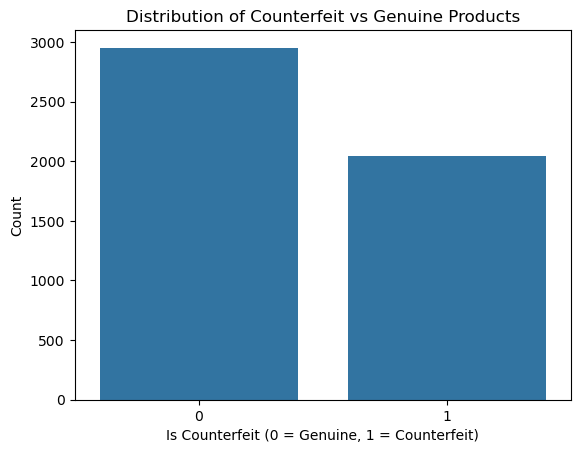

In [10]:
sns.countplot(data=cft_pdt_data, x='is_counterfeit')
plt.title('Distribution of Counterfeit vs Genuine Products')
plt.xlabel('Is Counterfeit (0 = Genuine, 1 = Counterfeit)')
plt.ylabel('Count')
plt.show()

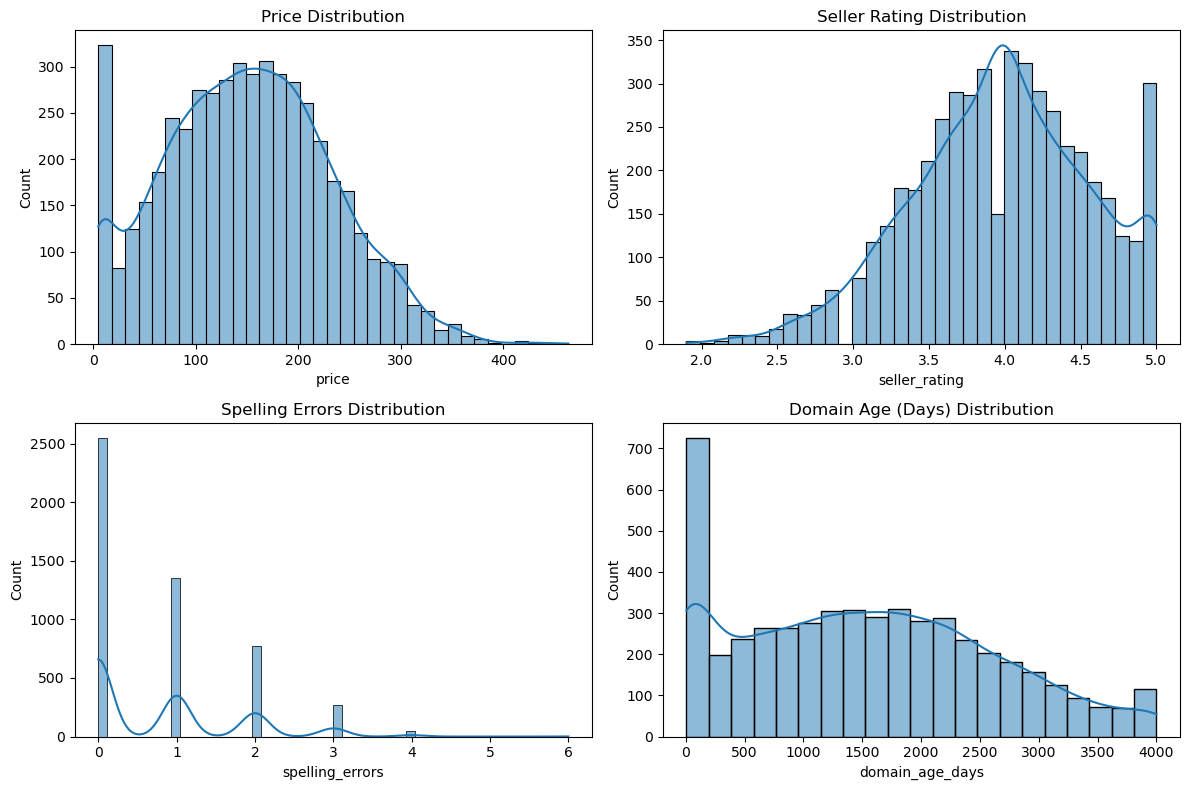

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(data=cft_pdt_data, x='price', kde=True, ax=axes[0,0])
axes[0,0].set_title('Price Distribution')

sns.histplot(data=cft_pdt_data, x='seller_rating', kde=True, ax=axes[0,1])
axes[0,1].set_title('Seller Rating Distribution')

sns.histplot(data=cft_pdt_data, x='spelling_errors', kde=True, ax=axes[1,0])
axes[1,0].set_title('Spelling Errors Distribution')

sns.histplot(data=cft_pdt_data, x='domain_age_days', kde=True, ax=axes[1,1])
axes[1,1].set_title('Domain Age (Days) Distribution')

plt.tight_layout()
plt.show()

In [12]:
cft_pdt_data.corr()

,price,seller_rating,seller_reviews,product_images,description_length,shipping_time_days,spelling_errors,domain_age_days,contact_info_complete,return_policy_clear,...,ip_location_mismatch,is_counterfeit,seller_country,shipping_origin,brand_suspicious,category_Cosmetics,category_Electronics,category_Fashion,category_Luxury Goods,category_Pharmaceuticals
price,1.000000,0.344014,0.286586,0.299577,0.309371,-0.299188,-0.256815,0.300901,0.126734,0.122486,...,-0.113863,-0.234280,-0.001813,0.004240,-0.114195,-0.014107,0.004036,0.008442,0.007748,0.004875
seller_rating,0.344014,1.000000,0.322855,0.298705,0.332927,-0.320803,-0.265189,0.314168,0.132644,0.116314,...,-0.117462,-0.261531,-0.005705,-0.000963,-0.146728,-0.013838,0.001379,0.010429,0.013369,-0.000075
seller_reviews,0.286586,0.322855,1.000000,0.253341,0.303346,-0.262229,-0.245554,0.296145,0.121684,0.088682,...,-0.086948,-0.219642,0.016116,0.005770,-0.123776,-0.035743,-0.003483,0.001744,0.005655,0.023648
product_images,0.299577,0.298705,0.253341,1.000000,0.288959,-0.253247,-0.214456,0.258116,0.094757,0.090594,...,-0.100653,-0.219100,-0.020884,-0.002897,-0.110496,-0.020835,-0.006200,0.032305,-0.004189,-0.006033
description_length,0.309371,0.332927,0.303346,0.288959,1.000000,-0.298423,-0.249100,0.293482,0.141335,0.102119,...,-0.104193,-0.201759,-0.005748,-0.019969,-0.123660,-0.015882,-0.014839,0.015129,-0.004518,0.040502
shipping_time_days,-0.299188,-0.320803,-0.262229,-0.253247,-0.298423,1.000000,0.247817,-0.269966,-0.100539,-0.097143,...,0.108436,0.220419,-0.003998,-0.008270,0.113919,0.017425,0.005086,-0.010530,-0.009836,-0.011224
spelling_errors,-0.256815,-0.265189,-0.245554,-0.214456,-0.249100,0.247817,1.000000,-0.232602,-0.108127,-0.084341,...,0.090530,0.168694,-0.001708,-0.000060,0.076646,0.023449,-0.004157,-0.009236,-0.008898,0.005001
domain_age_days,0.300901,0.314168,0.296145,0.258116,0.293482,-0.269966,-0.232602,1.000000,0.127108,0.084732,...,-0.104965,-0.211895,-0.016614,-0.008962,-0.106327,-0.029666,0.012848,0.016933,0.012531,0.000136
contact_info_complete,0.126734,0.132644,0.121684,0.094757,0.141335,-0.100539,-0.108127,0.127108,1.000000,0.037117,...,-0.037292,-0.080359,0.013278,-0.006387,-0.054521,-0.003952,-0.019856,0.003431,0.000312,0.019394
return_policy_clear,0.122486,0.116314,0.088682,0.090594,0.102119,-0.097143,-0.084341,0.084732,0.037117,1.000000,...,-0.048016,-0.080258,-0.014258,-0.011371,-0.029660,-0.014740,0.003172,0.020343,-0.013720,0.004736


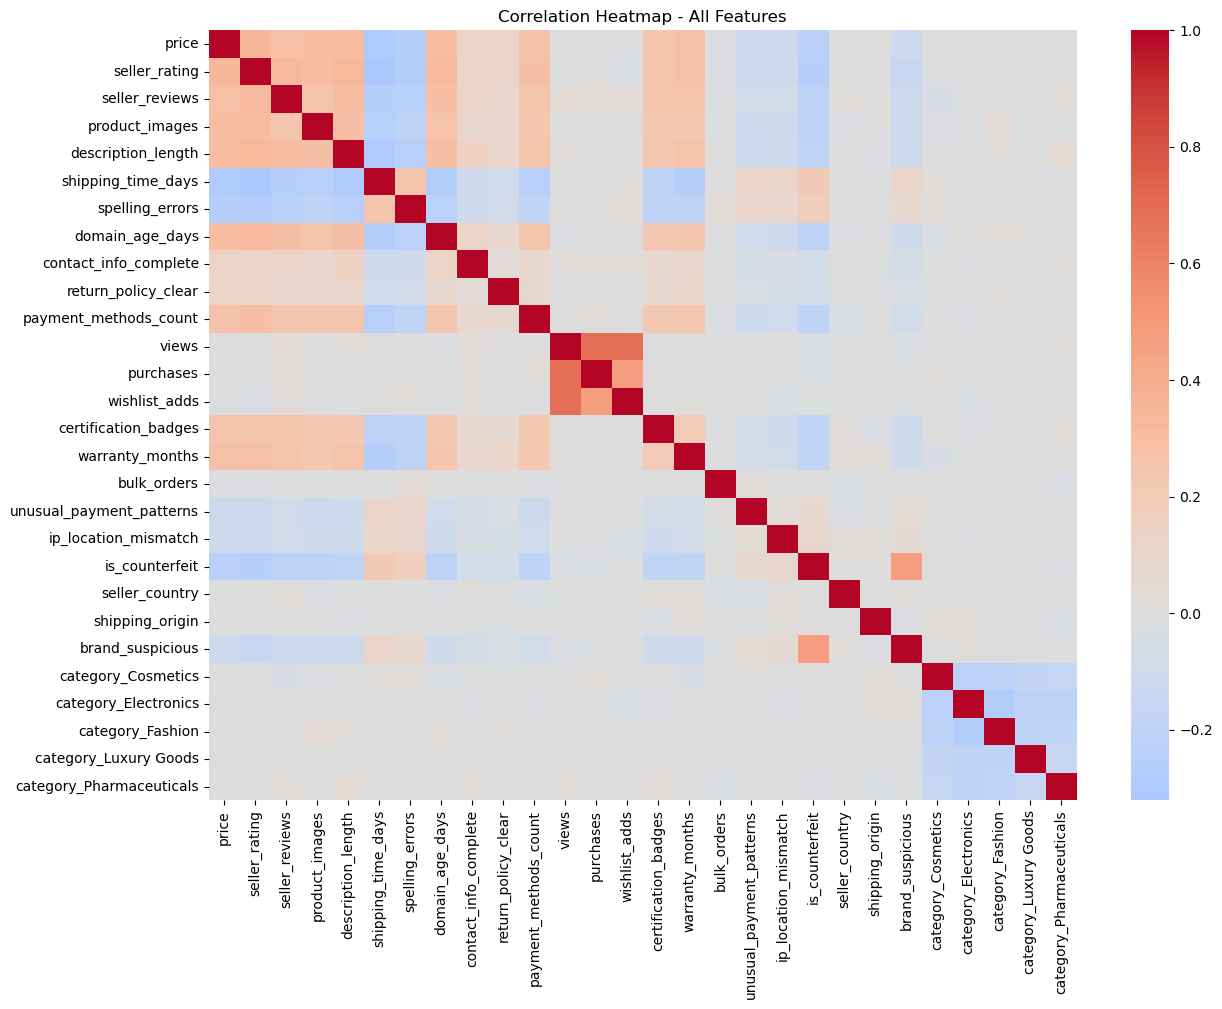

In [13]:
plt.figure(figsize=(14, 10))
sns.heatmap(cft_pdt_data.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - All Features')
plt.show()

In [14]:
correlation_with_target = cft_pdt_data.corr()['is_counterfeit'].sort_values(ascending=False)
print(correlation_with_target)

is_counterfeit              1.000000
brand_suspicious            0.478263
shipping_time_days          0.220419
spelling_errors             0.168694
ip_location_mismatch        0.094618
unusual_payment_patterns    0.076490
category_Cosmetics          0.011317
shipping_origin             0.011023
seller_country              0.009748
category_Electronics        0.008217
bulk_orders                 0.001187
category_Fashion           -0.001396
wishlist_adds              -0.003508
category_Luxury Goods      -0.015841
category_Pharmaceuticals   -0.020122
purchases                  -0.021811
views                      -0.025631
return_policy_clear        -0.080258
contact_info_complete      -0.080359
warranty_months            -0.187312
certification_badges       -0.196794
description_length         -0.201759
payment_methods_count      -0.202495
domain_age_days            -0.211895
product_images             -0.219100
seller_reviews             -0.219642
price                      -0.234280
s

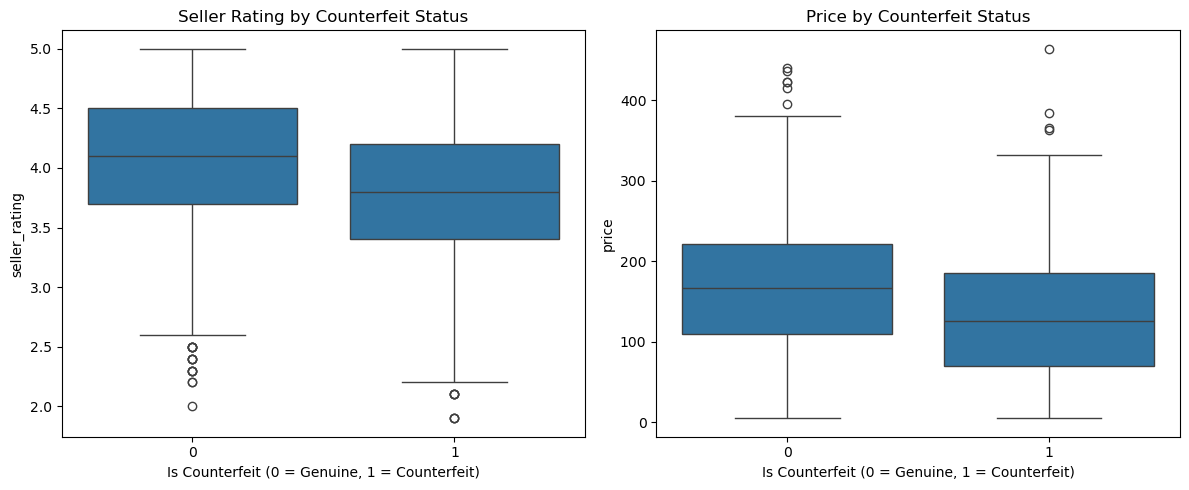

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=cft_pdt_data, x='is_counterfeit', y='seller_rating', ax=axes[0])
axes[0].set_title('Seller Rating by Counterfeit Status')
axes[0].set_xlabel('Is Counterfeit (0 = Genuine, 1 = Counterfeit)')

sns.boxplot(data=cft_pdt_data, x='is_counterfeit', y='price', ax=axes[1])
axes[1].set_title('Price by Counterfeit Status')
axes[1].set_xlabel('Is Counterfeit (0 = Genuine, 1 = Counterfeit)')

plt.tight_layout()
plt.show()